# BAIT 508 Group Project: Industry Analysis


Full name: Mengyuan (Wendy) Liu, Sicheng (Sisly) Lyu\
Email: wendaday@student.ubc.ca, slyu10@student.ubc.ca\
Student ID: 86527371, 72710643

## Part 1. Quantitative Analysis of the Industry Sector

### A. Industry Sector Selection and Data Filtering

In [980]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Read the dataset
df = pd.read_csv('data/public_firms.csv', index_col=0)

In [982]:
df.head(10)

,fyear,location,conm,ipodate,sic,prcc_c,ch,ni,asset,sale,roa
gvkey,,,,,,,,,,,
1004,1994,USA,AAR CORP,1988/01/01,5080,13.3750,22.487,10.463,425.814,451.395,0.024572
1004,1995,USA,AAR CORP,1988/01/01,5080,22.0000,33.606,16.012,437.846,504.990,0.036570
1004,1996,USA,AAR CORP,1988/01/01,5080,30.2500,51.705,23.025,529.584,589.328,0.043478
1004,1997,USA,AAR CORP,1988/01/01,5080,38.7500,17.222,35.657,670.559,782.123,0.053175
1004,1998,USA,AAR CORP,1988/01/01,5080,23.8750,8.250,41.671,726.630,918.036,0.057348
1004,1999,USA,AAR CORP,1988/01/01,5080,17.9375,1.241,35.163,740.998,1024.333,0.047454
1004,2000,USA,AAR CORP,1988/01/01,5080,12.6250,13.809,18.531,701.854,874.255,0.026403
1004,2001,USA,AAR CORP,1988/01/01,5080,9.0100,34.522,-58.939,710.199,638.721,-0.082989
1004,2002,USA,AAR CORP,1988/01/01,5080,5.1500,29.154,-12.410,686.621,606.337,-0.018074


### C1 (CITATION) （We used Chatgpt to get the initial code base filtering companies whose SIC codes start with 54.)

In [985]:
#(OpenAI, 2024)
df_food_store = df[df['sic'].astype(str).str.startswith('54')] 

In [987]:
df_food_store

,fyear,location,conm,ipodate,sic,prcc_c,ch,ni,asset,sale,roa
gvkey,,,,,,,,,,,
1240,1994,USA,ALBERTSON'S INC,NaN,5411,29.0000,50.224,400.365,3621.729,11894.621,0.110545
1240,1995,USA,ALBERTSON'S INC,NaN,5411,32.8750,69.113,464.961,4135.911,12585.034,0.112420
1240,1996,USA,ALBERTSON'S INC,NaN,5411,35.6250,90.865,493.779,4714.633,13776.678,0.104733
1240,1997,USA,ALBERTSON'S INC,NaN,5411,47.2500,108.083,516.814,5218.590,14689.511,0.099033
1240,1998,USA,ALBERTSON'S INC,NaN,5411,63.6875,80.646,567.153,6233.968,16005.115,0.090978
...,...,...,...,...,...,...,...,...,...,...,...
205677,2003,CHL,WALMART CHILE SA,1997/10/07,5411,20.6600,50.861,33.727,1368.456,1884.060,0.024646
205677,2004,CHL,WALMART CHILE SA,1997/10/07,5411,18.1000,40.828,18.560,1856.734,2581.307,0.009996
205677,2005,CHL,WALMART CHILE SA,1997/10/07,5411,19.2900,40.382,82.362,2146.684,3108.003,0.038367


### a.	How many unique firm-year ("fyear") observations are there in the filtered dataset?

In [345]:
unique_firm_years = df_food_store['fyear'].nunique()
print(unique_firm_years)

27


### b.	How many unique firms are there in the filtered dataset?

In [347]:
unique_firms = df_food_store['conm'].nunique()
print(unique_firms)

104


### c.	How many firms in the filtered dataset have records over all 27 years (1994-2020)?

In [349]:
df_food_store.groupby('conm')[['fyear']].count()

,fyear
conm,
7-ELEVEN INC,10
ALBERTSON'S INC,12
ALBERTSONS COS INC,3
ALIMENTATION COUCHE-TARD INC,1
AMERICAN STORES CO,5
...,...
WEIS MARKETS INC,26
WESTERN BEEF INC,4
WHOLE FOODS MARKET INC,22


In [350]:
(df_food_store.groupby(['conm'])['fyear'].count() ==27).sum()

1

## B. Preliminary Analysis

### 1.	What are the top 10 firms with the highest stock price (column "prcc_c") in the year 2020?

In [353]:
df_food_store[df_food_store['fyear'] == 2020][['conm','prcc_c']].sort_values(by='prcc_c', ascending=False).head(10)

,conm,prcc_c
gvkey,,
2807,CASEYS GENERAL STORES INC,178.620
11343,WEIS MARKETS INC,47.810
12972,INGLES MARKETS INC -CL A,42.660
189579,GROCERY OUTLET HLDNG CORP,39.250
6502,KROGER CO,31.760
23667,KONINKLIJKE AHOLD DELHAIZE,28.276
11178,VILLAGE SUPER MARKET -CL A,22.060
17934,SPROUTS FARMERS MARKET,20.100
25645,ALBERTSONS COS INC,17.580


### 2.	What are the top 10 firms with the highest sales (column "sale") in the entire history of the dataset?

### There are two different thought processes to solve this problem.

### Approach 1

In [382]:
df_food_store[['conm', 'sale']].sort_values(by='sale', ascending=False).head(10)

,conm,sale
gvkey,,
6502,KROGER CO,132498.0
6502,KROGER CO,122662.0
6502,KROGER CO,122286.0
6502,KROGER CO,121162.0
6502,KROGER CO,115337.0
6502,KROGER CO,109830.0
6502,KROGER CO,108465.0
6502,KROGER CO,98375.0
6502,KROGER CO,96751.0


### Approach 2

In [580]:
df_food_store[df_food_store['fyear'] == 1994][['conm','sale']].sort_values(by='sale', ascending=False).head(10)

,conm,sale
gvkey,,
100384,DAIEI INC,33235.763
6197,ITO-YOKADO CO LTD,31206.752
1573,AMERICAN STORES CO,18355.126
1240,ALBERTSON'S INC,11894.621
5301,GREAT ATLANTIC & PAC TEA CO,10331.950
10199,SUPERMARKETS GEN HLDG -CL A,4205.536
29846,PATHMARK STORES INC,4181.994
10095,STOP & SHOP COS,3788.963
5151,GIANT FOOD INC -CL A,3695.627


In [582]:
df_food_store[df_food_store['fyear'] == 1995][['conm','sale']].sort_values(by='sale', ascending=False).head(10)

,conm,sale
gvkey,,
100384,DAIEI INC,30095.100
6197,ITO-YOKADO CO LTD,26655.467
6502,KROGER CO,23937.795
23667,KONINKLIJKE AHOLD DELHAIZE,18481.951
1573,AMERICAN STORES CO,18308.894
9359,SAFEWAY INC,16397.500
1240,ALBERTSON'S INC,12585.034
11535,WINN-DIXIE STORES INC,11787.843
5301,GREAT ATLANTIC & PAC TEA CO,10101.356


In [584]:
df_food_store[df_food_store['fyear'] == 1996][['conm','sale']].sort_values(by='sale', ascending=False).head(10)

,conm,sale
gvkey,,
100384,DAIEI INC,26022.680
6502,KROGER CO,25170.909
6197,ITO-YOKADO CO LTD,24083.810
23667,KONINKLIJKE AHOLD DELHAIZE,20892.483
1573,AMERICAN STORES CO,18678.129
9359,SAFEWAY INC,17269.000
1240,ALBERTSON'S INC,13776.678
11535,WINN-DIXIE STORES INC,12955.488
8815,PUBLIX SUPER MARKETS INC,10431.302


In [586]:
df_food_store[df_food_store['fyear'] == 1997][['conm','sale']].sort_values(by='sale', ascending=False).head(10)

,conm,sale
gvkey,,
6502,KROGER CO,26567.348
23667,KONINKLIJKE AHOLD DELHAIZE,24935.318
100384,DAIEI INC,24868.381
6197,ITO-YOKADO CO LTD,23717.039
9359,SAFEWAY INC,22483.800
1573,AMERICAN STORES CO,19138.880
1240,ALBERTSON'S INC,14689.511
11535,WINN-DIXIE STORES INC,13218.715
8815,PUBLIX SUPER MARKETS INC,11224.378


In [588]:
df_food_store[df_food_store['fyear'] == 1998][['conm','sale']].sort_values(by='sale', ascending=False).head(10)

,conm,sale
gvkey,,
23667,KONINKLIJKE AHOLD DELHAIZE,30945.662
6502,KROGER CO,28203.304
6197,ITO-YOKADO CO LTD,26085.900
100384,DAIEI INC,25266.958
9359,SAFEWAY INC,24484.200
1573,AMERICAN STORES CO,19866.725
1240,ALBERTSON'S INC,16005.115
12681,MEYER (FRED) INC,14878.771
11535,WINN-DIXIE STORES INC,13617.485


In [590]:
df_food_store[df_food_store['fyear'] == 1999][['conm','sale']].sort_values(by='sale', ascending=False).head(10)

,conm,sale
gvkey,,
6502,KROGER CO,45352.000
1240,ALBERTSON'S INC,37478.079
23667,KONINKLIJKE AHOLD DELHAIZE,33795.314
6197,ITO-YOKADO CO LTD,29308.227
9359,SAFEWAY INC,28859.900
100384,DAIEI INC,25883.000
100781,DELHAIZE GROUP - ETS DLHZ FR,14701.543
11535,WINN-DIXIE STORES INC,14136.503
8815,PUBLIX SUPER MARKETS INC,13068.900


In [592]:
df_food_store[df_food_store['fyear'] == 2000][['conm','sale']].sort_values(by='sale', ascending=False).head(10)

,conm,sale
gvkey,,
23667,KONINKLIJKE AHOLD DELHAIZE,49448.512
6502,KROGER CO,49000.000
1240,ALBERTSON'S INC,36762.000
9359,SAFEWAY INC,31976.900
6197,ITO-YOKADO CO LTD,26755.233
100781,DELHAIZE GROUP - ETS DLHZ FR,17439.833
8815,PUBLIX SUPER MARKETS INC,14575.031
11535,WINN-DIXIE STORES INC,13697.547
4828,DELHAIZE AMERICA INC,12669.932


In [594]:
df_food_store[df_food_store['fyear'] == 2001][['conm','sale']].sort_values(by='sale', ascending=False).head(10)

,conm,sale
gvkey,,
23667,KONINKLIJKE AHOLD DELHAIZE,58841.632
6502,KROGER CO,50098.000
1240,ALBERTSON'S INC,37931.000
9359,SAFEWAY INC,34301.000
6197,ITO-YOKADO CO LTD,22350.498
100781,DELHAIZE GROUP - ETS DLHZ FR,19511.012
8815,PUBLIX SUPER MARKETS INC,15370.019
4828,DELHAIZE AMERICA INC,14913.227
11535,WINN-DIXIE STORES INC,12903.373


In [596]:
df_food_store[df_food_store['fyear'] == 2002][['conm','sale']].sort_values(by='sale', ascending=False).head(10)

,conm,sale
gvkey,,
23667,KONINKLIJKE AHOLD DELHAIZE,65723.126
6502,KROGER CO,51760.000
1240,ALBERTSON'S INC,35626.000
9359,SAFEWAY INC,32399.200
6197,ITO-YOKADO CO LTD,25257.525
100781,DELHAIZE GROUP - ETS DLHZ FR,22105.089
8815,PUBLIX SUPER MARKETS INC,16026.664
4828,DELHAIZE AMERICA INC,15043.477
11535,WINN-DIXIE STORES INC,12334.353


In [954]:
df_food_store[df_food_store['fyear'] == 2003][['conm','sale']].sort_values(by='sale', ascending=False).head(10)

,conm,sale
gvkey,,
23667,KONINKLIJKE AHOLD DELHAIZE,70628.860
6502,KROGER CO,53791.000
9359,SAFEWAY INC,35552.700
1240,ALBERTSON'S INC,35436.000
6197,ITO-YOKADO CO LTD,32201.327
100781,DELHAIZE GROUP - ETS DLHZ FR,24175.190
8815,PUBLIX SUPER MARKETS INC,16946.318
4828,DELHAIZE AMERICA INC,15553.174
11535,WINN-DIXIE STORES INC,12168.383


In [600]:
df_food_store[df_food_store['fyear'] == 2004][['conm','sale']].sort_values(by='sale', ascending=False).head(10)

,conm,sale
gvkey,,
23667,KONINKLIJKE AHOLD DELHAIZE,70397.600
6502,KROGER CO,56434.000
1240,ALBERTSON'S INC,39897.000
9359,SAFEWAY INC,35822.900
6197,ITO-YOKADO CO LTD,34510.048
100781,DELHAIZE GROUP - ETS DLHZ FR,24809.605
8815,PUBLIX SUPER MARKETS INC,18686.371
4828,DELHAIZE AMERICA INC,15839.882
9872,7-ELEVEN INC,12235.283


In [602]:
df_food_store[df_food_store['fyear'] == 2005][['conm','sale']].sort_values(by='sale', ascending=False).head(10)

,conm,sale
gvkey,,
6502,KROGER CO,60553.000
23667,KONINKLIJKE AHOLD DELHAIZE,52692.163
1240,ALBERTSON'S INC,40358.000
9359,SAFEWAY INC,38416.000
174413,SUPERVALU INC -PRO FORMA,33462.000
100781,DELHAIZE GROUP - ETS DLHZ FR,22145.961
8815,PUBLIX SUPER MARKETS INC,20744.811
4828,DELHAIZE AMERICA INC,16564.900
11535,WINN-DIXIE STORES INC,9921.319


In [604]:
df_food_store[df_food_store['fyear'] == 2006][['conm','sale']].sort_values(by='sale', ascending=False).head(10)

,conm,sale
gvkey,,
6502,KROGER CO,66111.000
23667,KONINKLIJKE AHOLD DELHAIZE,59217.578
9359,SAFEWAY INC,40185.000
100781,DELHAIZE GROUP - ETS DLHZ FR,25473.641
8815,PUBLIX SUPER MARKETS INC,21819.725
4828,DELHAIZE AMERICA INC,17289.200
11535,WINN-DIXIE STORES INC,7193.853
5301,GREAT ATLANTIC & PAC TEA CO,6850.268
63904,COMPANHIA BRASILEIRA DE DIST,6503.797


In [606]:
df_food_store[df_food_store['fyear'] == 2007][['conm','sale']].sort_values(by='sale', ascending=False).head(10)

,conm,sale
gvkey,,
6502,KROGER CO,70235.000
9359,SAFEWAY INC,42286.000
23667,KONINKLIJKE AHOLD DELHAIZE,41110.366
100781,DELHAIZE GROUP - ETS DLHZ FR,27806.449
8815,PUBLIX SUPER MARKETS INC,23193.590
63904,COMPANHIA BRASILEIRA DE DIST,8377.115
11535,WINN-DIXIE STORES INC,7201.161
24893,WHOLE FOODS MARKET INC,6591.773
5301,GREAT ATLANTIC & PAC TEA CO,6401.130


In [608]:
df_food_store[df_food_store['fyear'] == 2008][['conm','sale']].sort_values(by='sale', ascending=False).head(10)

,conm,sale
gvkey,,
6502,KROGER CO,76000.000
9359,SAFEWAY INC,44104.000
23667,KONINKLIJKE AHOLD DELHAIZE,35802.452
100781,DELHAIZE GROUP - ETS DLHZ FR,26590.857
8815,PUBLIX SUPER MARKETS INC,24109.584
5301,GREAT ATLANTIC & PAC TEA CO,9516.186
24893,WHOLE FOODS MARKET INC,7953.912
63904,COMPANHIA BRASILEIRA DE DIST,7779.599
11535,WINN-DIXIE STORES INC,7281.449


In [610]:
df_food_store[df_food_store['fyear'] == 2009][['conm','sale']].sort_values(by='sale', ascending=False).head(10)

,conm,sale
gvkey,,
6502,KROGER CO,76733.000
9359,SAFEWAY INC,40850.700
23667,KONINKLIJKE AHOLD DELHAIZE,40022.110
100781,DELHAIZE GROUP - ETS DLHZ FR,28678.333
8815,PUBLIX SUPER MARKETS INC,24514.960
63904,COMPANHIA BRASILEIRA DE DIST,13337.469
5301,GREAT ATLANTIC & PAC TEA CO,8813.568
24893,WHOLE FOODS MARKET INC,8031.620
11535,WINN-DIXIE STORES INC,7366.965


In [612]:
df_food_store[df_food_store['fyear'] == 2010][['conm','sale']].sort_values(by='sale', ascending=False).head(10)

,conm,sale
gvkey,,
6502,KROGER CO,82189.000
9359,SAFEWAY INC,41050.000
23667,KONINKLIJKE AHOLD DELHAIZE,39183.357
100781,DELHAIZE GROUP - ETS DLHZ FR,27773.344
8815,PUBLIX SUPER MARKETS INC,25328.054
63904,COMPANHIA BRASILEIRA DE DIST,19296.297
160381,CENCOSUD SA,13598.029
24893,WHOLE FOODS MARKET INC,9005.794
5301,GREAT ATLANTIC & PAC TEA CO,8078.455


In [614]:
df_food_store[df_food_store['fyear'] == 2011][['conm','sale']].sort_values(by='sale', ascending=False).head(10)

,conm,sale
gvkey,,
6502,KROGER CO,90374.000
9359,SAFEWAY INC,43630.200
23667,KONINKLIJKE AHOLD DELHAIZE,39270.568
100781,DELHAIZE GROUP - ETS DLHZ FR,27530.003
8815,PUBLIX SUPER MARKETS INC,27178.764
63904,COMPANHIA BRASILEIRA DE DIST,25014.488
160381,CENCOSUD SA,14787.744
24893,WHOLE FOODS MARKET INC,10107.787
11535,WINN-DIXIE STORES INC,6880.776


In [616]:
df_food_store[df_food_store['fyear'] == 2012][['conm','sale']].sort_values(by='sale', ascending=False).head(10)

,conm,sale
gvkey,,
6502,KROGER CO,96751.000
9359,SAFEWAY INC,44206.500
23667,KONINKLIJKE AHOLD DELHAIZE,43304.143
100781,DELHAIZE GROUP - ETS DLHZ FR,30127.373
8815,PUBLIX SUPER MARKETS INC,27706.772
63904,COMPANHIA BRASILEIRA DE DIST,24870.317
160381,CENCOSUD SA,19345.431
24893,WHOLE FOODS MARKET INC,11698.828
18775,SOUTHEASTERN GROCERS -REDH,8632.861


In [618]:
df_food_store[df_food_store['fyear'] == 2013][['conm','sale']].sort_values(by='sale', ascending=False).head(10)

,conm,sale
gvkey,,
6502,KROGER CO,98375.000
23667,KONINKLIJKE AHOLD DELHAIZE,44940.209
9359,SAFEWAY INC,36139.100
100781,DELHAIZE GROUP - ETS DLHZ FR,29219.747
8815,PUBLIX SUPER MARKETS INC,29147.518
63904,COMPANHIA BRASILEIRA DE DIST,24453.686
160381,CENCOSUD SA,19896.331
24893,WHOLE FOODS MARKET INC,12917.000
2807,CASEYS GENERAL STORES INC,7194.255


In [620]:
df_food_store[df_food_store['fyear'] == 2014][['conm','sale']].sort_values(by='sale', ascending=False).head(10)

,conm,sale
gvkey,,
6502,KROGER CO,108465.000
23667,KONINKLIJKE AHOLD DELHAIZE,39659.817
8815,PUBLIX SUPER MARKETS INC,30802.466
100781,DELHAIZE GROUP - ETS DLHZ FR,25979.637
63904,COMPANHIA BRASILEIRA DE DIST,24667.771
160381,CENCOSUD SA,17872.846
24893,WHOLE FOODS MARKET INC,14194.000
2807,CASEYS GENERAL STORES INC,7052.216
26799,SAVE-A-LOT INC -SPN,4641.000


In [622]:
df_food_store[df_food_store['fyear'] == 2015][['conm','sale']].sort_values(by='sale', ascending=False).head(10)

,conm,sale
gvkey,,
6502,KROGER CO,109830.000
23667,KONINKLIJKE AHOLD DELHAIZE,41484.638
8815,PUBLIX SUPER MARKETS INC,32618.759
100781,DELHAIZE GROUP - ETS DLHZ FR,26609.979
63904,COMPANHIA BRASILEIRA DE DIST,17482.888
160381,CENCOSUD SA,15817.024
24893,WHOLE FOODS MARKET INC,15389.000
2807,CASEYS GENERAL STORES INC,6304.086
19843,SMART & FINAL STORES INC,3970.980


In [624]:
df_food_store[df_food_store['fyear'] == 2016][['conm','sale']].sort_values(by='sale', ascending=False).head(10)

,conm,sale
gvkey,,
6502,KROGER CO,115337.000
23667,KONINKLIJKE AHOLD DELHAIZE,52438.164
8815,PUBLIX SUPER MARKETS INC,34274.109
160381,CENCOSUD SA,15908.694
24893,WHOLE FOODS MARKET INC,15724.000
63904,COMPANHIA BRASILEIRA DE DIST,12742.530
2807,CASEYS GENERAL STORES INC,6640.587
19843,SMART & FINAL STORES INC,4341.795
17934,SPROUTS FARMERS MARKET,4046.385


In [626]:
df_food_store[df_food_store['fyear'] == 2017][['conm','sale']].sort_values(by='sale', ascending=False).head(10)

,conm,sale
gvkey,,
6502,KROGER CO,122662.000
23667,KONINKLIJKE AHOLD DELHAIZE,75606.358
8815,PUBLIX SUPER MARKETS INC,34836.838
63904,COMPANHIA BRASILEIRA DE DIST,13476.042
2807,CASEYS GENERAL STORES INC,7472.124
17934,SPROUTS FARMERS MARKET,4664.612
19843,SMART & FINAL STORES INC,4570.565
12972,INGLES MARKETS INC -CL A,4002.700
11343,WEIS MARKETS INC,3466.807


In [628]:
df_food_store[df_food_store['fyear'] == 2018][['conm','sale']].sort_values(by='sale', ascending=False).head(10)

,conm,sale
gvkey,,
6502,KROGER CO,121162.000
23667,KONINKLIJKE AHOLD DELHAIZE,71889.265
25645,ALBERTSONS COS INC,60534.500
8815,PUBLIX SUPER MARKETS INC,36395.718
63904,COMPANHIA BRASILEIRA DE DIST,12757.399
18775,SOUTHEASTERN GROCERS -REDH,8772.512
2807,CASEYS GENERAL STORES INC,8364.910
17934,SPROUTS FARMERS MARKET,5207.336
19843,SMART & FINAL STORES INC,4741.772


In [630]:
df_food_store[df_food_store['fyear'] == 2019][['conm','sale']].sort_values(by='sale', ascending=False).head(10)

,conm,sale
gvkey,,
6502,KROGER CO,122286.000
23667,KONINKLIJKE AHOLD DELHAIZE,74355.824
25645,ALBERTSONS COS INC,62455.100
8815,PUBLIX SUPER MARKETS INC,38462.753
63904,COMPANHIA BRASILEIRA DE DIST,14089.600
18775,SOUTHEASTERN GROCERS -REDH,8277.374
2807,CASEYS GENERAL STORES INC,8112.296
17934,SPROUTS FARMERS MARKET,5634.835
12972,INGLES MARKETS INC -CL A,4202.034


In [632]:
df_food_store[df_food_store['fyear'] == 2020][['conm','sale']].sort_values(by='sale', ascending=False).head(10)

,conm,sale
gvkey,,
6502,KROGER CO,132498.000
23667,KONINKLIJKE AHOLD DELHAIZE,90085.728
25645,ALBERTSONS COS INC,69690.400
64655,ALIMENTATION COUCHE-TARD INC,45760.100
63904,COMPANHIA BRASILEIRA DE DIST,9589.608
2807,CASEYS GENERAL STORES INC,7654.189
38181,SENDAS DISTRIBUIDORA S.A.,6855.317
17934,SPROUTS FARMERS MARKET,6468.759
12972,INGLES MARKETS INC -CL A,4610.609


### 3.	What is the geographical distribution (column "location") of all the firms? In other words, how many firms are there in each location? Please list the top 10 locations. 

In [384]:
df_food_store.groupby(['location'])[['conm']].count().sort_values(by='conm',ascending=False).head(10)

,conm
location,
USA,737
CHN,35
CHL,34
BRA,27
NLD,26
BEL,17
JPN,17
ISR,7
ARG,5


### 4.	Create a line chart to show the average stock price (column "prcc_c") in the selected sector(s) across the years. If you have selected multiple sectors, draw multiple lines to show them separately.

In [386]:
average_prcc_c = df_food_store.groupby('fyear')[['prcc_c']].mean()
average_prcc_c.head()

,prcc_c
fyear,
1994,32.920111
1995,25.453771
1996,26.002491
1997,27.701491
1998,21.481619


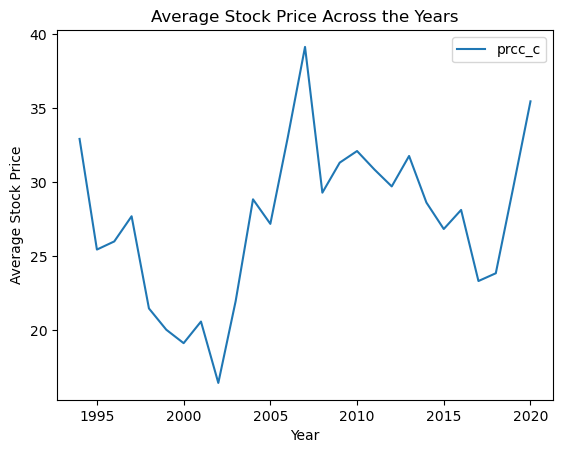

In [387]:
# Plot the line chart
average_prcc_c.plot(kind='line')
plt.title('Average Stock Price Across the Years')
plt.xlabel('Year')
plt.ylabel('Average Stock Price')
plt.show()


### 5.	Which firm was affected the most by the 2008 Financial Crisis, as measured by the percentage drop in stock price from 2007 to 2008?

In [389]:
prcc_c_2007 = df_food_store[df_food_store['fyear'] == 2007][['conm','prcc_c']]
prcc_c_2007.head()

,conm,prcc_c
gvkey,,
1728,ARDEN GROUP INC -CL A,154.69
2807,CASEYS GENERAL STORES INC,29.61
5301,GREAT ATLANTIC & PAC TEA CO,31.33
6502,KROGER CO,26.71
8439,PENN TRAFFIC CO,13.50


In [390]:
prcc_c_2008 = df_food_store[df_food_store['fyear'] == 2008][['conm','prcc_c']]
prcc_c_2008.head()

,conm,prcc_c
gvkey,,
1728,ARDEN GROUP INC -CL A,126.00
2807,CASEYS GENERAL STORES INC,22.77
5301,GREAT ATLANTIC & PAC TEA CO,6.27
6502,KROGER CO,26.41
8439,PENN TRAFFIC CO,0.70


In [1010]:
import pandas as pd
help(pd.merge)

Help on function merge in module pandas.core.reshape.merge:

merge(left: 'DataFrame | Series', right: 'DataFrame | Series', how: 'MergeHow' = 'inner', on: 'IndexLabel | AnyArrayLike | None' = None, left_on: 'IndexLabel | AnyArrayLike | None' = None, right_on: 'IndexLabel | AnyArrayLike | None' = None, left_index: 'bool' = False, right_index: 'bool' = False, sort: 'bool' = False, suffixes: 'Suffixes' = ('_x', '_y'), copy: 'bool | None' = None, indicator: 'str | bool' = False, validate: 'str | None' = None) -> 'DataFrame'
    Merge DataFrame or named Series objects with a database-style join.

    A named Series object is treated as a DataFrame with a single named column.

    The join is done on columns or indexes. If joining columns on
    columns, the DataFrame indexes *will be ignored*. Otherwise if joining indexes
    on indexes or indexes on a column or columns, the index will be passed on.
    When performing a cross merge, no column specifications to merge on are
    allowed.

  

In [391]:
prcc_07_08 = pd.merge(prcc_c_2007, prcc_c_2008, on='conm', suffixes=('_2007', '_2008'))
prcc_07_08.head()

,conm,prcc_c_2007,prcc_c_2008
0,ARDEN GROUP INC -CL A,154.69,126.00
1,CASEYS GENERAL STORES INC,29.61,22.77
2,GREAT ATLANTIC & PAC TEA CO,31.33,6.27
3,KROGER CO,26.71,26.41
4,PENN TRAFFIC CO,13.50,0.70


In [392]:
prcc_07_08['change_per'] = ((prcc_07_08['prcc_c_2008'] - prcc_07_08['prcc_c_2007'])/ prcc_07_08['prcc_c_2007'])*100
prcc_07_08.head()

,conm,prcc_c_2007,prcc_c_2008,change_per
0,ARDEN GROUP INC -CL A,154.69,126.00,-18.546771
1,CASEYS GENERAL STORES INC,29.61,22.77,-23.100304
2,GREAT ATLANTIC & PAC TEA CO,31.33,6.27,-79.987233
3,KROGER CO,26.71,26.41,-1.123175
4,PENN TRAFFIC CO,13.50,0.70,-94.814815


In [393]:
prcc_07_08[['conm', 'change_per']].sort_values(by='change_per', ascending=True).head(1)

,conm,change_per
4,PENN TRAFFIC CO,-94.814815


### 6.	Plot the average Return on Assets (ROA) for the firms located in the “USA” across the years. 
ROA is calculated as ni/asset.

In [395]:
usa = df_food_store[df_food_store['location']=='USA']
usa.head()

,fyear,location,conm,ipodate,sic,prcc_c,ch,ni,asset,sale,roa
gvkey,,,,,,,,,,,
1240,1994,USA,ALBERTSON'S INC,NaN,5411,29.0000,50.224,400.365,3621.729,11894.621,0.110545
1240,1995,USA,ALBERTSON'S INC,NaN,5411,32.8750,69.113,464.961,4135.911,12585.034,0.112420
1240,1996,USA,ALBERTSON'S INC,NaN,5411,35.6250,90.865,493.779,4714.633,13776.678,0.104733
1240,1997,USA,ALBERTSON'S INC,NaN,5411,47.2500,108.083,516.814,5218.590,14689.511,0.099033
1240,1998,USA,ALBERTSON'S INC,NaN,5411,63.6875,80.646,567.153,6233.968,16005.115,0.090978


In [396]:
average_roa=usa.groupby(['fyear'])[['roa']].mean()
average_roa.head()

,roa
fyear,
1994,0.003943
1995,0.012492
1996,0.015932
1997,0.006678
1998,-0.159778


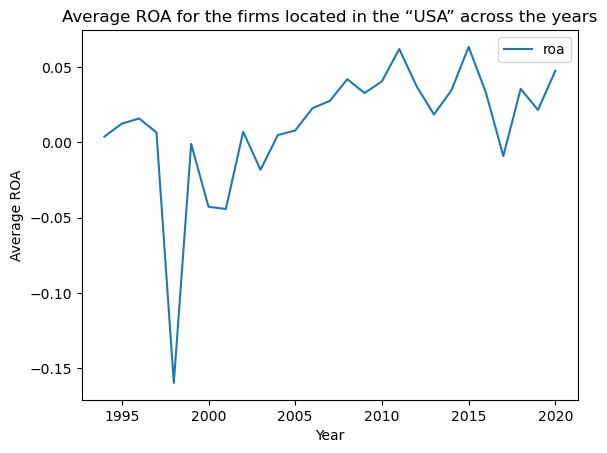

In [397]:
average_roa.plot(kind='line')
plt.title('Average ROA for the firms located in the “USA” across the years')
plt.xlabel('Year')
plt.ylabel('Average ROA')
plt.show()


## Part 2. Text Analysis on the Industry Sector

### C. Load the dataset as a DataFrame and create a new column containing the cleaned text for each “item_1” content. Follow the steps below to clean the text.
The file "data/2020_10K_item1_full.csv" contains a sample of 5,988 firms and their “item_1” content in their 10-K reports in the year 2020.2

In [400]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df1 = pd.read_csv('data/2020_10K_item1_full.csv', index_col=0)

In [401]:
df1.head(10)

,year,name,item_1_text,gvkey
cik,,,,
1041588,2020,ACCESS-POWER INC,fixed expenses are previosuly documented in an...,66119
315374,2020,HURCO COMPANIES INC,"General Hurco Companies, Inc. is an internatio...",5788
1622996,2020,"ACRO BIOMEDICAL CO., LTD.",We have been engaged in the business of develo...,27584
1191334,2020,Chun Can Capital Group,CORPORATE HISTORY Chun Can Capital Group (form...,153614
1191334,2020,Chun Can Capital Group,CORPORATE HISTORY Chun Can Capital Group (form...,153614
1191334,2020,Chun Can Capital Group,CORPORATE HISTORY Chun Can Capital Group (form...,153614
1191334,2020,Chun Can Capital Group,CORPORATE HISTORY Chun Can Capital Group (form...,153614
1191334,2020,Chun Can Capital Group,CORPORATE HISTORY Chun Can Capital Group (form...,153614
1191334,2020,Chun Can Capital Group,CORPORATE HISTORY Chun Can Capital Group (form...,153614


In [402]:
!pip3 install nltk

In [403]:
import nltk
import string

1. Convert all words into lowercase.

In [405]:
df1['item_1_text']=df1['item_1_text'].str.lower()
df1.head(5)

,year,name,item_1_text,gvkey
cik,,,,
1041588,2020,ACCESS-POWER INC,fixed expenses are previosuly documented in an...,66119
315374,2020,HURCO COMPANIES INC,"general hurco companies, inc. is an internatio...",5788
1622996,2020,"ACRO BIOMEDICAL CO., LTD.",we have been engaged in the business of develo...,27584
1191334,2020,Chun Can Capital Group,corporate history chun can capital group (form...,153614
1191334,2020,Chun Can Capital Group,corporate history chun can capital group (form...,153614


2. Remove punctuations.

In [407]:
puncs = string.punctuation
translator = str.maketrans('', '', string.punctuation)
df1['item_1_text'] = df1['item_1_text'].str.translate(translator)
df1.head(5)

,year,name,item_1_text,gvkey
cik,,,,
1041588,2020,ACCESS-POWER INC,fixed expenses are previosuly documented in an...,66119
315374,2020,HURCO COMPANIES INC,general hurco companies inc is an internationa...,5788
1622996,2020,"ACRO BIOMEDICAL CO., LTD.",we have been engaged in the business of develo...,27584
1191334,2020,Chun Can Capital Group,corporate history chun can capital group forme...,153614
1191334,2020,Chun Can Capital Group,corporate history chun can capital group forme...,153614


3. Remove stop words based on the list of English stop words in NLTK

In [409]:
from nltk.corpus import stopwords
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /Users/sisly/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [410]:
import string

translator = str.maketrans('', '', string.punctuation)
sw = stopwords.words('english')

def clean_text(text):
    ''' This function takes a string as input and 
        returns a cleaned version of the string
        Specifically, it makes the string into lower case and remove punctuations
    '''
    text_lower = text.lower() # make it lowercase
    text_no_punctuation = text_lower.translate(translator) # remove punctuation  
    clean_words = [w for w in text_no_punctuation.split() if w not in sw] # remove stopwords
    return ' '.join(clean_words)
df1['item_1_text_clean'] = df1['item_1_text'].apply(clean_text)
df1.head(5)

,year,name,item_1_text,gvkey,item_1_text_clean
cik,,,,,
1041588,2020,ACCESS-POWER INC,fixed expenses are previosuly documented in an...,66119,fixed expenses previosuly documented 8k 235000...
315374,2020,HURCO COMPANIES INC,general hurco companies inc is an internationa...,5788,general hurco companies inc international indu...
1622996,2020,"ACRO BIOMEDICAL CO., LTD.",we have been engaged in the business of develo...,27584,engaged business developing marketing products...
1191334,2020,Chun Can Capital Group,corporate history chun can capital group forme...,153614,corporate history chun capital group formerly ...
1191334,2020,Chun Can Capital Group,corporate history chun can capital group forme...,153614,corporate history chun capital group formerly ...


### D. Conduct keywords analysis on your selected industry sector(s). Follow the steps below to complete the analysis.

1. Create a new DataFrame that includes only firms in your selected industry sector(s).\
Ensure that you merge the 10-K data with the previous "public_firm.csv" data using an `inner join`.

In [1014]:
help(df1.merge)

Help on method merge in module pandas.core.frame:

merge(right: 'DataFrame | Series', how: 'MergeHow' = 'inner', on: 'IndexLabel | AnyArrayLike | None' = None, left_on: 'IndexLabel | AnyArrayLike | None' = None, right_on: 'IndexLabel | AnyArrayLike | None' = None, left_index: 'bool' = False, right_index: 'bool' = False, sort: 'bool' = False, suffixes: 'Suffixes' = ('_x', '_y'), copy: 'bool | None' = None, indicator: 'str | bool' = False, validate: 'MergeValidate | None' = None) -> 'DataFrame' method of pandas.core.frame.DataFrame instance
    Merge DataFrame or named Series objects with a database-style join.

    A named Series object is treated as a DataFrame with a single named column.

    The join is done on columns or indexes. If joining columns on
    columns, the DataFrame indexes *will be ignored*. Otherwise if joining indexes
    on indexes or indexes on a column or columns, the index will be passed on.
    When performing a cross merge, no column specifications to merge on a

In [992]:
import pandas as pd

df1_merged = df1.merge(df_food_store, how='inner', left_on=['gvkey', 'year'], right_on=['gvkey', 'fyear'])
df1_merged


,year,name,item_1_text,gvkey,item_1_text_clean,fyear,location,conm,ipodate,sic,prcc_c,ch,ni,asset,sale,roa
0,2020,"Sprouts Farmers Market, Inc.",sprouts farmers market operates as a healthy g...,17934,sprouts farmers market operates healthy grocer...,2020,USA,SPROUTS FARMERS MARKET,2013/08/01,5411,20.10,169.697,287.450,2806.404,6468.759,0.102426
1,2020,WEIS MARKETS INC,weis markets inc is a pennsylvania business fo...,11343,weis markets inc pennsylvania business founded...,2020,USA,WEIS MARKETS INC,NaN,5411,47.81,136.612,118.917,1820.421,4112.601,0.065324
2,2020,Grocery Outlet Holding Corp.,our company we are a highgrowth extreme value ...,189579,company highgrowth extreme value retailer qual...,2020,USA,GROCERY OUTLET HLDNG CORP,2019/06/20,5411,39.25,105.326,106.713,2485.624,3134.640,0.042932
3,2020,KROGER CO,corporate history turnkey capital inc the com...,6502,corporate history turnkey capital inc company ...,2020,USA,KROGER CO,NaN,5411,31.76,1687.000,2585.000,48662.000,132498.000,0.053122
4,2020,"Albertsons Companies, Inc.",overview albertsons is one of the largest food...,25645,overview albertsons one largest food drug reta...,2020,USA,ALBERTSONS COS INC,2020/06/26,5411,17.58,1717.000,850.200,26598.000,69690.400,0.031965
5,2020,CASEYS GENERAL STORES INC,the company casey s general stores inc casey ...,2807,company casey general stores inc casey whollyo...,2020,USA,CASEYS GENERAL STORES INC,NaN,5412,178.62,336.545,312.900,4460.314,7654.189,0.070152
6,2020,VILLAGE SUPER MARKET INC,jw mays inc the company or registrant with...,11178,jw mays inc company registrant executive offic...,2020,USA,VILLAGE SUPER MARKET -CL A,NaN,5411,22.06,111.681,24.939,915.546,1804.594,0.027239
7,2020,INGLES MARKETS INC,general ingles markets incorporated a north ca...,12972,general ingles markets incorporated north caro...,2020,USA,INGLES MARKETS INC -CL A,NaN,5411,42.66,6.904,178.601,1899.299,4610.609,0.094035
8,2020,"Natural Grocers by Vitamin Cottage, Inc.",general natural grocers is an expanding specia...,11922,general natural grocers expanding specialty re...,2020,USA,NATURAL GROCERS VITAMIN CTGE,2012/07/25,5400,13.74,28.534,20.009,681.792,1036.842,0.029348


In [414]:
print(df1_merged['conm'].unique())

['SPROUTS FARMERS MARKET' 'WEIS MARKETS INC' 'GROCERY OUTLET HLDNG CORP'
 'KROGER CO' 'ALBERTSONS COS INC' 'CASEYS GENERAL STORES INC'
 'VILLAGE SUPER MARKET  -CL A' 'INGLES MARKETS INC  -CL A'
 'NATURAL GROCERS VITAMIN CTGE']


In [415]:
df1_merged[df1_merged['conm'] == 'CASEYS GENERAL STORES INC']

,year,name,item_1_text,gvkey,item_1_text_clean,fyear,location,conm,ipodate,sic,prcc_c,ch,ni,asset,sale,roa
5,2020,CASEYS GENERAL STORES INC,the company casey s general stores inc casey ...,2807,company casey general stores inc casey whollyo...,2020,USA,CASEYS GENERAL STORES INC,NaN,5412,178.62,336.545,312.9,4460.314,7654.189,0.070152


In [416]:
df1_merged[df1_merged['conm'] == 'KROGER CO']

,year,name,item_1_text,gvkey,item_1_text_clean,fyear,location,conm,ipodate,sic,prcc_c,ch,ni,asset,sale,roa
3,2020,KROGER CO,corporate history turnkey capital inc the com...,6502,corporate history turnkey capital inc company ...,2020,USA,KROGER CO,NaN,5411,31.76,1687.0,2585.0,48662.0,132498.0,0.053122


2. Generate the top 10 keywords for each firm based on two different methods: word counts and
TF-IDF score.

**Word Counts Method:**

In [690]:
from collections import Counter

In [692]:
def get_top_keywords(text):
    c = Counter(text.split())
    lst = c.most_common(10)
    string = []
    for pair in lst:
        string.append(pair[0])
    return ' '.join(string)

In [694]:
df1_merged['top_keywords_1'] = df1_merged['item_1_text_clean'].apply(get_top_keywords)
df1_merged.head()

,year,name,item_1_text,gvkey,item_1_text_clean,fyear,location,conm,ipodate,sic,prcc_c,ch,ni,asset,sale,roa,top_keywords_2,top_keywords_1
0,2020,"Sprouts Farmers Market, Inc.",sprouts farmers market operates as a healthy g...,17934,sprouts farmers market operates healthy grocer...,2020,USA,SPROUTS FARMERS MARKET,2013/08/01,5411,20.10,169.697,287.450,2806.404,6468.759,0.102426,sprouts stores food believe customers store pr...,stores food store customers products believe s...
1,2020,WEIS MARKETS INC,weis markets inc is a pennsylvania business fo...,11343,weis markets inc pennsylvania business founded...,2020,USA,WEIS MARKETS INC,NaN,5411,47.81,136.612,118.917,1820.421,4112.601,0.065324,weis stores company store food markets product...,company stores weis store food products ﻿ 1 ma...
2,2020,Grocery Outlet Holding Corp.,our company we are a highgrowth extreme value ...,189579,company highgrowth extreme value retailer qual...,2020,USA,GROCERY OUTLET HLDNG CORP,2019/06/20,5411,39.25,105.326,106.713,2485.624,3134.640,0.042932,ios store io wow us vice stores products offic...,store ios us stores products customers busines...
3,2020,KROGER CO,corporate history turnkey capital inc the com...,6502,corporate history turnkey capital inc company ...,2020,USA,KROGER CO,NaN,5411,31.76,1687.000,2585.000,48662.000,132498.000,0.053122,medixall company egg rom agreement exchange st...,company exchange egg inc agreement stock medix...
4,2020,"Albertsons Companies, Inc.",overview albertsons is one of the largest food...,25645,overview albertsons one largest food drug reta...,2020,USA,ALBERTSONS COS INC,2020/06/26,5411,17.58,1717.000,850.200,26598.000,69690.400,0.031965,pension plants brands felra plan new fiscal fo...,brands new pension food fiscal plan similar 20...


**TF-IDF Score Method:**

In [697]:
!pip3 install scikit-learn

In [698]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [699]:
def get_keywords_tfidf(document_list):
    '''
    This function gets a list of documents as input and returns a list of top 10 keywords for each document using TF-IDF scores.
    Input: A list of documents (text)
    Output: The corresponding top 10 keywords for each document based on tf-idf values
    '''
    vectorizer = TfidfVectorizer() # Step 1: Create a TF-IDF vectorizer
    tfidf_matrix = vectorizer.fit_transform(document_list) # Step 2: Calculate the TF-IDF matrix
    feature_names = vectorizer.get_feature_names_out() # Step 3: Get feature names (words)

    # Step 4: Extract top 10 keywords for each document
    top_keywords = [] # accumulator
    for i in range(len(document_list)):
        feature_index = tfidf_matrix[i, :].nonzero()[1]
        feature_value = [tfidf_matrix[i, x] for x in feature_index]
        tfidf_scores = zip(feature_index, feature_value)
        sorted_tfidf_scores = sorted(tfidf_scores, key=lambda x: x[1], reverse=True)
        top_keywords.append(' '.join([feature_names[i] for i, _ in sorted_tfidf_scores[:10]]))

        if i % 200 == 199:
            print(f'Processed {i+1}/{len(document_list)} documents.')
    
    return top_keywords

In [791]:
text1 = df1_merged['item_1_text_clean'].tolist()# This process will take several minutes.
tfidf_keywords = get_keywords_tfidf(text1)

# add a new column in the dataframe
df1_merged['top_keywords_2'] = get_keywords_tfidf(text1)
df1_merged.head(10)

,year,name,item_1_text,gvkey,item_1_text_clean,fyear,location,conm,ipodate,sic,prcc_c,ch,ni,asset,sale,roa,top_keywords_2,top_keywords_1
0,2020,"Sprouts Farmers Market, Inc.",sprouts farmers market operates as a healthy g...,17934,sprouts farmers market operates healthy grocer...,2020,USA,SPROUTS FARMERS MARKET,2013/08/01,5411,20.10,169.697,287.450,2806.404,6468.759,0.102426,sprouts stores food believe customers store pr...,stores food store customers products believe s...
1,2020,WEIS MARKETS INC,weis markets inc is a pennsylvania business fo...,11343,weis markets inc pennsylvania business founded...,2020,USA,WEIS MARKETS INC,NaN,5411,47.81,136.612,118.917,1820.421,4112.601,0.065324,weis stores company store food markets product...,company stores weis store food products ﻿ 1 ma...
2,2020,Grocery Outlet Holding Corp.,our company we are a highgrowth extreme value ...,189579,company highgrowth extreme value retailer qual...,2020,USA,GROCERY OUTLET HLDNG CORP,2019/06/20,5411,39.25,105.326,106.713,2485.624,3134.640,0.042932,ios store io wow us vice stores products offic...,store ios us stores products customers busines...
3,2020,KROGER CO,corporate history turnkey capital inc the com...,6502,corporate history turnkey capital inc company ...,2020,USA,KROGER CO,NaN,5411,31.76,1687.000,2585.000,48662.000,132498.000,0.053122,medixall company egg rom agreement exchange st...,company exchange egg inc agreement stock medix...
4,2020,"Albertsons Companies, Inc.",overview albertsons is one of the largest food...,25645,overview albertsons one largest food drug reta...,2020,USA,ALBERTSONS COS INC,2020/06/26,5411,17.58,1717.000,850.200,26598.000,69690.400,0.031965,pension plants brands felra plan new fiscal fo...,brands new pension food fiscal plan similar 20...
5,2020,CASEYS GENERAL STORES INC,the company casey s general stores inc casey ...,2807,company casey general stores inc casey whollyo...,2020,USA,CASEYS GENERAL STORES INC,NaN,5412,178.62,336.545,312.900,4460.314,7654.189,0.070152,casey stores fuel company store april iowa pro...,stores company casey store fuel products april...
6,2020,VILLAGE SUPER MARKET INC,jw mays inc the company or registrant with...,11178,jw mays inc company registrant executive offic...,2020,USA,VILLAGE SUPER MARKET -CL A,NaN,5411,22.06,111.681,24.939,915.546,1804.594,0.027239,forwardlooking statements company rates result...,company statements forwardlooking market resul...
7,2020,INGLES MARKETS INC,general ingles markets incorporated a north ca...,12972,general ingles markets incorporated north caro...,2020,USA,INGLES MARKETS INC -CL A,NaN,5411,42.66,6.904,178.601,1899.299,4610.609,0.094035,company stores ingles store carolina products ...,company stores store products customer custome...
8,2020,"Natural Grocers by Vitamin Cottage, Inc.",general natural grocers is an expanding specia...,11922,general natural grocers expanding specialty re...,2020,USA,NATURAL GROCERS VITAMIN CTGE,2012/07/25,5400,13.74,28.534,20.009,681.792,1036.842,0.029348,crew products dietary members store nutrition ...,products store stores customers health members...


3. Create two wordclouds to visualize the keywords across all firms in the selected sector(s): one
based on the word counts and another based on the TF-IDF scores

**Word Counts Method (CASEYS GENERAL STORES INC):**

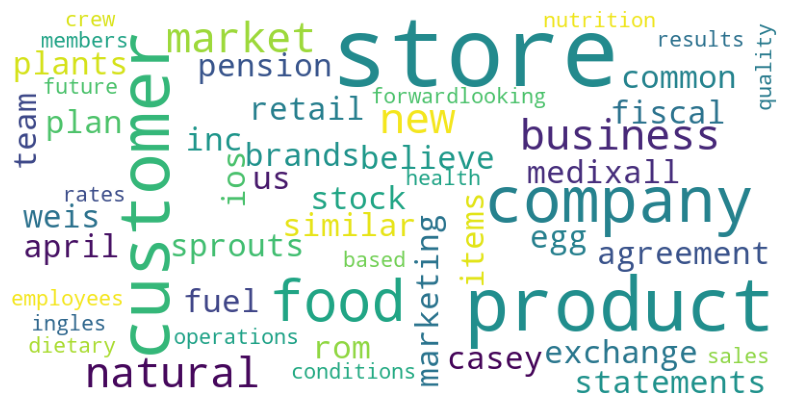

In [707]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt


cgsi_df1 = df1_merged[df1_merged['conm'].str.contains('CASEYS GENERAL STORES INC', case=False)]
top_keywords_1 = ' '.join(df1_merged['top_keywords_1'].tolist())

# lower max_font_size
wordcloud_1 = WordCloud(width=800, height=400, max_font_size=100, background_color='white').generate(top_keywords_1) # note that text is a string, not a list

plt.figure(figsize=(10,5))
plt.axis('off')
plt.imshow(wordcloud_1)
plt.savefig('CGSI1.png') # save as PNG file
plt.show()

**Word Counts Method (KROGER CO):**

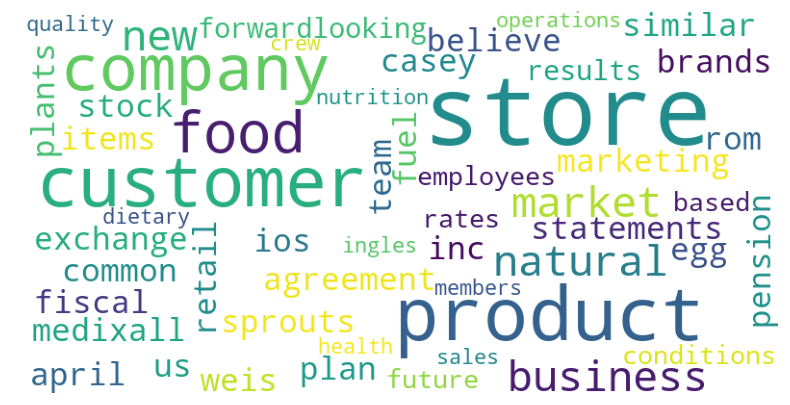

In [710]:
kc_df1 = df1_merged[df1_merged['conm'].str.contains('KROGER CO', case=False)]
top_keywords_1 = ' '.join(df1_merged['top_keywords_1'].tolist())

# lower max_font_size
wordcloud_2 = WordCloud(width=800, height=400, max_font_size=100, background_color='white').generate(top_keywords_1) # note that text is a string, not a list

plt.figure(figsize=(10,5))
plt.axis('off')
plt.imshow(wordcloud_2)
plt.savefig('KC1.png') # save as PNG file
plt.show()

**TF-IDF Score Method (CASEYS GENERAL STORES INC):**

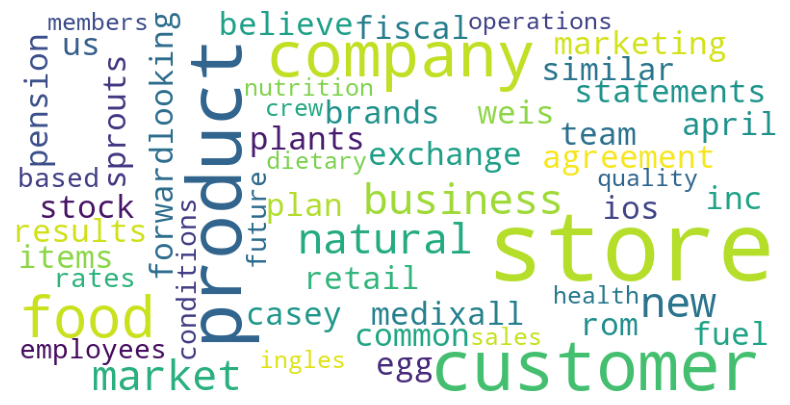

In [713]:
cgsi_df2 = df1_merged[df1_merged['conm'].str.contains('CASEYS GENERAL STORES INC', case=False)]
top_keywords_2 = ' '.join(df1_merged['top_keywords_2'].tolist())

# lower max_font_size
wordcloud_3 = WordCloud(width=800, height=400, max_font_size=100, background_color='white').generate(top_keywords_1) # note that text is a string, not a list

plt.figure(figsize=(10,5))
plt.axis('off')
plt.imshow(wordcloud_3)
plt.savefig('CGSI2.png') # save as PNG file
plt.show()

**TF-IDF Score Method (KROGER CO):**

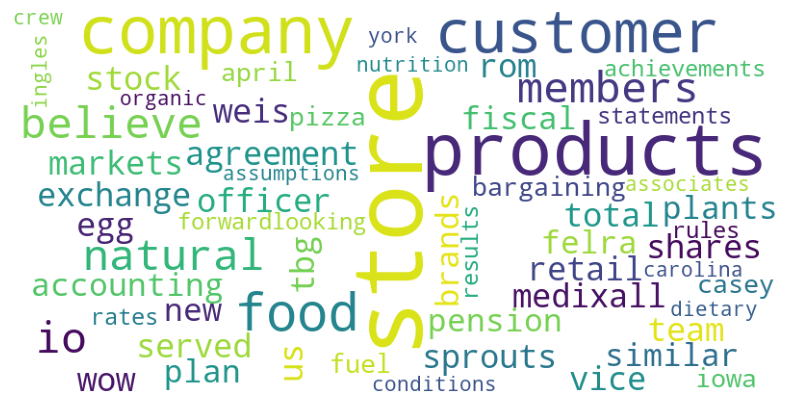

In [716]:
kc_df2 = df1_merged[df1_merged['conm'].str.contains('KROGER CO', case=False)]
top_keywords_2 = ' '.join(df1_merged['top_keywords_2'].tolist())

# lower max_font_size
wordcloud_4 = WordCloud(width=800, height=400, max_font_size=100, background_color='white').generate(top_keywords_2) # note that text is a string, not a list

plt.figure(figsize=(10,5))
plt.axis('off')
plt.imshow(wordcloud_4)
plt.savefig('KC2.png') # save as PNG file
plt.show()

### E. Train a word2vec model and analyze word similarities

1. Train a word2vec model with the full 10-K sample (e.g., "data/2020_10K_item1_full.csv"). Please use the cleaned text (e.g., results from Step C) for training.

In [755]:
!pip3 install gensim

In [768]:
import pandas as pd
from gensim.models import Word2Vec

In [770]:
docs = [row.split() for row in df1_merged['item_1_text_clean']]

In [772]:
model = Word2Vec(docs, min_count=5, vector_size=50, workers=3, window=5, sg = 1)

In [774]:
model = Word2Vec.load("word2vec.model")

In [776]:
model.save("word2vec.model")

2. Manually inspect the wordclouds you generated in D.3 and choose three representative
keywords that are relevant to the industry sector of your interest. Utilize the trained word2vec
model to find the most relevant five words for each of these three keywords

In [779]:
model.wv.most_similar('customer')[0:5]

[('provide', 0.9903064966201782),
 ('customers', 0.9895921945571899),
 ('engagement', 0.9894888997077942),
 ('experience', 0.9885426163673401),
 ('providing', 0.9884974360466003)]

In [781]:
model.wv.most_similar('natural')[0:5]

[('foods', 0.9889939427375793),
 ('organic', 0.9852707982063293),
 ('fresh', 0.983290433883667),
 ('produce', 0.9784092903137207),
 ('products', 0.9780416488647461)]

In [783]:
model.wv.most_similar('believe')[0:5]

[('model', 0.9951387643814087),
 ('sourcing', 0.9945012331008911),
 ('key', 0.9941527247428894),
 ('robust', 0.9938037395477295),
 ('brand', 0.9936527609825134)]

## Part 3. Comprehensive Analysis of One Sample Firm

### F. This is an open question. Pick one firm that your group is interested in and try to analyze its market status. The ultimate goal is to provide one valuable suggestion to the firm based on your analysis. Some directions you might consider are, but not limited to:

1. Convert the keywords extracted in D.2 into word embeddings with the word2vec model trained
in E.1. Add up the embeddings for each firm to create the firm-level embeddings. Use the firm-level embeddings to find the focal firm’s competing firms (or most similar firms)

#### Our group is interested in CASEYS GENERAL STORES INC and try to analyze its market status.

In [809]:
from DocumentSimilarity import DocumentSimilarity
docsim = DocumentSimilarity(model = model, gvkeys=df1_merged['gvkey'], conm = df1_merged['conm'], 
                       keywordslist = df1_merged['top_keywords_1'])

In [811]:
# create firm-level embeddings, 2807 is the gvkey for CASEYS GENERAL STORES INC
caseys_gvkey = 2807
docsim.get_firm_embedding(firm = caseys_gvkey) 

array([-0.11283748, -0.08852949,  0.02031948,  0.11158061, -0.18317524,
       -0.06116899,  0.00335648,  0.30141875, -0.16182987, -0.08858047,
        0.08154782, -0.24371776, -0.04822849,  0.21317522, -0.12367569,
        0.09299064,  0.06459115,  0.08716974, -0.18979989,  0.06555092,
       -0.14255604,  0.20947449,  0.14793362, -0.01856599,  0.0876473 ,
       -0.02678681, -0.11799522, -0.03167107, -0.17296408,  0.16338786,
        0.08681218, -0.00928227, -0.06695282, -0.02035035, -0.15557428,
        0.2993985 ,  0.1800921 , -0.10390423,  0.06187213, -0.09604176,
        0.2871368 , -0.05872881, -0.09430037, -0.04138676,  0.30025083,
        0.00988676,  0.07394907, -0.17480364,  0.04749388, -0.04110593],
      dtype=float32)

In [817]:
# CASEYS GENERAL STORES INC's most similar firms
caseys_similar_firms = docsim.most_similar(firm = 2807, topn = 5)
caseys_similar_firms

[(11343, 'WEIS MARKETS INC', 0.9978114),
 (25645, 'ALBERTSONS COS INC', 0.99760765),
 (12972, 'INGLES MARKETS INC  -CL A', 0.99487066),
 (189579, 'GROCERY OUTLET HLDNG CORP', 0.99196696),
 (17934, 'SPROUTS FARMERS MARKET', 0.99143)]

2. Compare the revenue, market share, and ROA of the focal firm to its competitors and provide
suggestions accordingly

### C2 (CITATION) （We used Chatgpt to get the initial code base filtering competitors' dataframe.)

In [974]:
firms_gvkey = [2807, 11343, 25645, 12972, 189579, 17934]

In [976]:
#(OpenAI, 2024)
df_competitors = df1_merged[df1_merged['gvkey'].isin(firms_gvkey)] 

df_competitors = df_competitors[['conm', 'sale', 'roa',]]
df_competitors

,conm,sale,roa
0,SPROUTS FARMERS MARKET,6468.759,0.102426
1,WEIS MARKETS INC,4112.601,0.065324
2,GROCERY OUTLET HLDNG CORP,3134.640,0.042932
4,ALBERTSONS COS INC,69690.400,0.031965
5,CASEYS GENERAL STORES INC,7654.189,0.070152
7,INGLES MARKETS INC -CL A,4610.609,0.094035


**Revenue**

In [862]:
df_competitors['revenue'] = df_competitors['sale']

**Market Share**

In [865]:
total_revenue = df_competitors['sale'].sum()
df_competitors['market_share %'] = df_competitors['sale'] / total_revenue * 100

**ROA**

In [868]:
df_competitors['roa']

0    0.102426
1    0.065324
2    0.042932
4    0.031965
5    0.070152
7    0.094035
Name: roa, dtype: float64

In [870]:
df_competitors

,conm,sale,roa,revenue,market_share %
0,SPROUTS FARMERS MARKET,6468.759,0.102426,6468.759,6.761449
1,WEIS MARKETS INC,4112.601,0.065324,4112.601,4.298682
2,GROCERY OUTLET HLDNG CORP,3134.640,0.042932,3134.640,3.276472
4,ALBERTSONS COS INC,69690.400,0.031965,69690.400,72.843658
5,CASEYS GENERAL STORES INC,7654.189,0.070152,7654.189,8.000515
7,INGLES MARKETS INC -CL A,4610.609,0.094035,4610.609,4.819224


### C3 (CITATION) Visualization （We used Chatgpt to get the initial code base.)

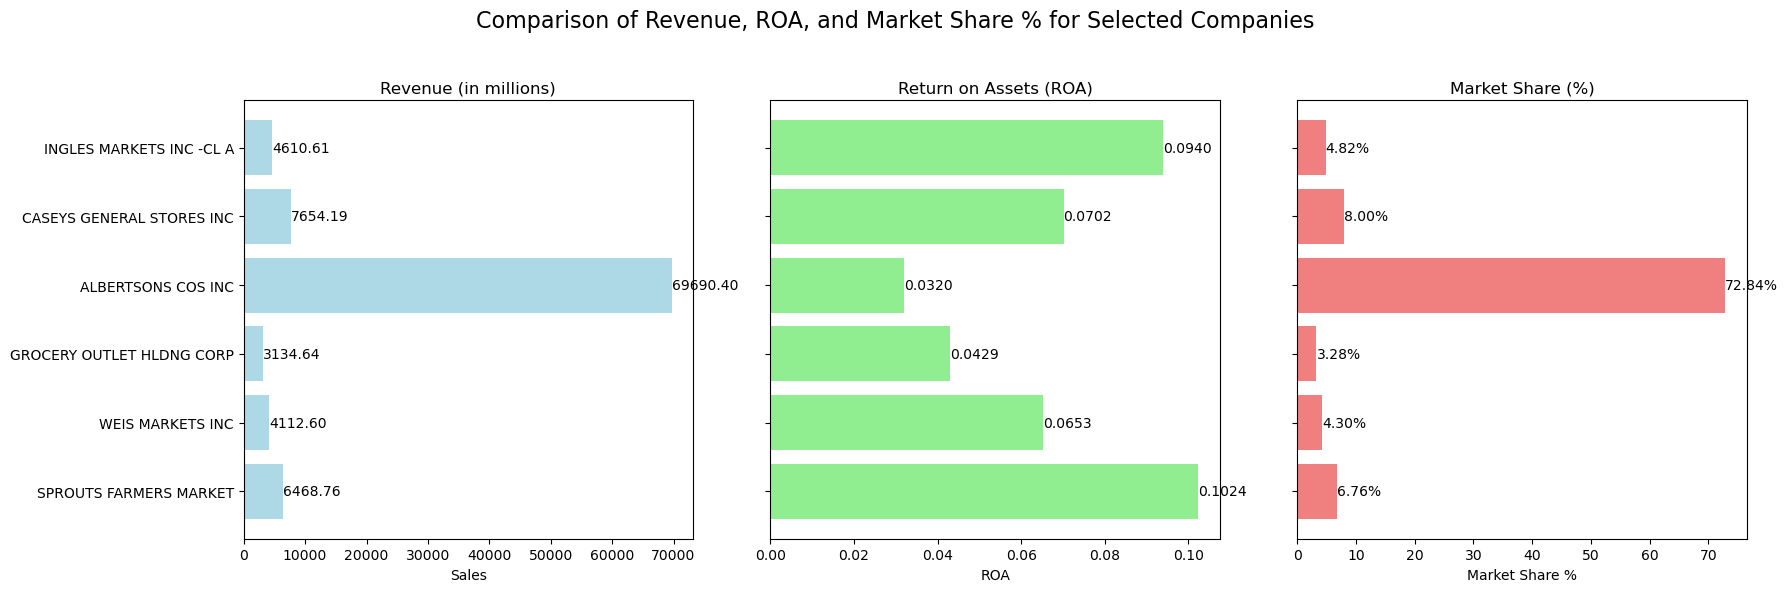

In [23]:
import matplotlib.pyplot as plt
import pandas as pd
#(OpenAI, 2024)
# Sample data
data = {
    'conm': ['SPROUTS FARMERS MARKET', 'WEIS MARKETS INC', 'GROCERY OUTLET HLDNG CORP', 
             'ALBERTSONS COS INC', 'CASEYS GENERAL STORES INC', 'INGLES MARKETS INC -CL A'],
    'sale': [6468.759, 4112.601, 3134.640, 69690.400, 7654.189, 4610.609],
    'roa': [0.102426, 0.065324, 0.042932, 0.031965, 0.070152, 0.094035]
}

# Create DataFrame
df = pd.DataFrame(data)

# Calculate market share as percentage of total sales
df['market_share'] = (df['sale'] / df['sale'].sum()) * 100

# Set up subplots for horizontal bar chart with title and numbers beside the bars, sharing the same company names
fig, axs = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

# Add title to the overall chart
fig.suptitle('Comparison of Revenue, ROA, and Market Share % for Selected Companies', fontsize=16)

# Plot revenue (sales) horizontally with numbers beside the bars
axs[0].barh(df['conm'], df['sale'], color='lightblue')
for index, value in enumerate(df['sale']):
    axs[0].text(value, index, f'{value:.2f}', va='center')
axs[0].set_title('Revenue (in millions)')
axs[0].set_xlabel('Sales')

# Plot ROA horizontally with numbers beside the bars
axs[1].barh(df['conm'], df['roa'], color='lightgreen')
for index, value in enumerate(df['roa']):
    axs[1].text(value, index, f'{value:.4f}', va='center')
axs[1].set_title('Return on Assets (ROA)')
axs[1].set_xlabel('ROA')

# Plot Market Share horizontally with numbers beside the bars
axs[2].barh(df['conm'], df['market_share'], color='lightcoral')
for index, value in enumerate(df['market_share']):
    axs[2].text(value, index, f'{value:.2f}%', va='center')
axs[2].set_title('Market Share (%)')
axs[2].set_xlabel('Market Share %')

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust to fit title

# Display the chart
plt.show()


3. Perform an analysis of the historical stock prices, ROA, revenue, and assets of the chosen firm.
Investigate potential correlations and address noteworthy decreases and increases.

In [907]:
caseys_data = df_food_store[df_food_store['conm'] == 'CASEYS GENERAL STORES INC']

**Historical Stock Prices**

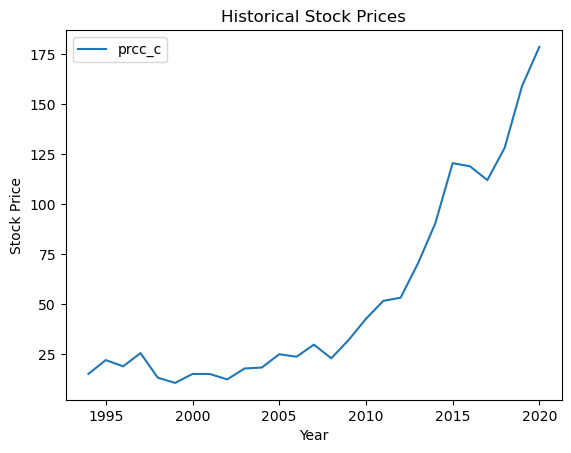

In [911]:
caseys_data.plot(x='fyear', y='prcc_c', title='Historical Stock Prices')
plt.xlabel("Year")
plt.ylabel("Stock Price")
plt.show()

**ROA**

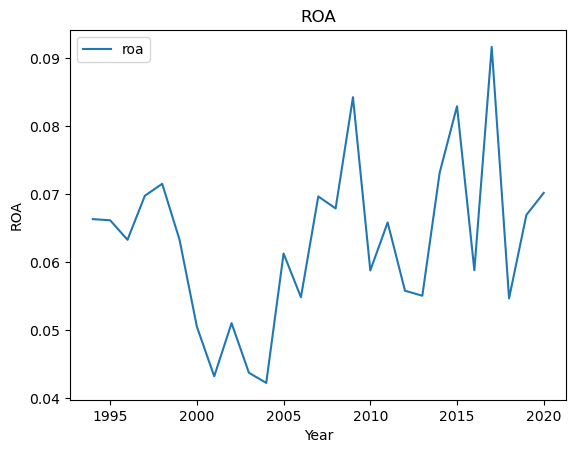

In [919]:
caseys_data.plot(x='fyear', y='roa', title='ROA')
plt.xlabel("Year")
plt.ylabel("ROA")
plt.show()

**Revenue**

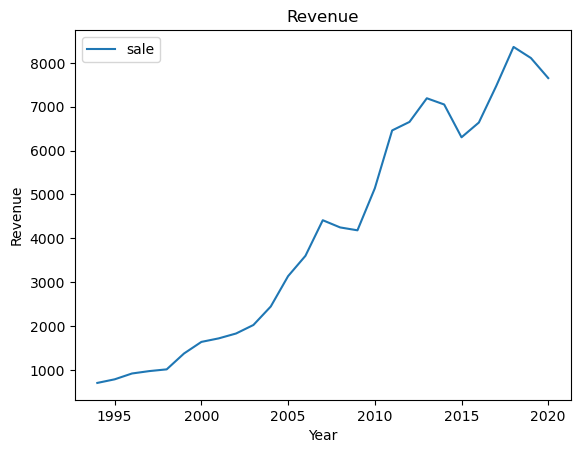

In [915]:
caseys_data.plot(x='fyear', y='sale', title='Revenue')
plt.xlabel("Year")
plt.ylabel("Revenue")
plt.show()

**Assets**

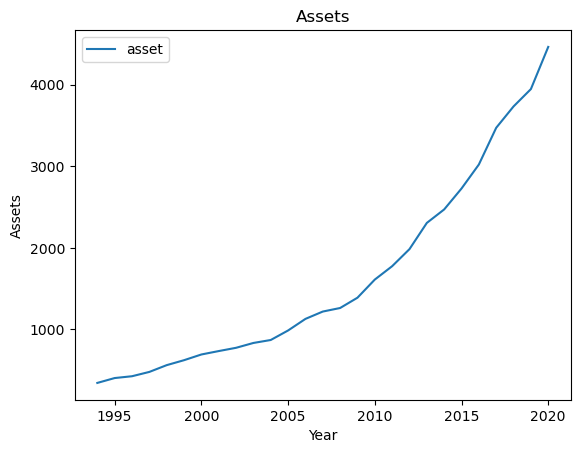

In [917]:
caseys_data.plot(x='fyear', y='asset', title='Assets')
plt.xlabel("Year")
plt.ylabel("Assets")
plt.show()

### C4 (CITATION) Visualization （We used Chatgpt to get the initial code base.)

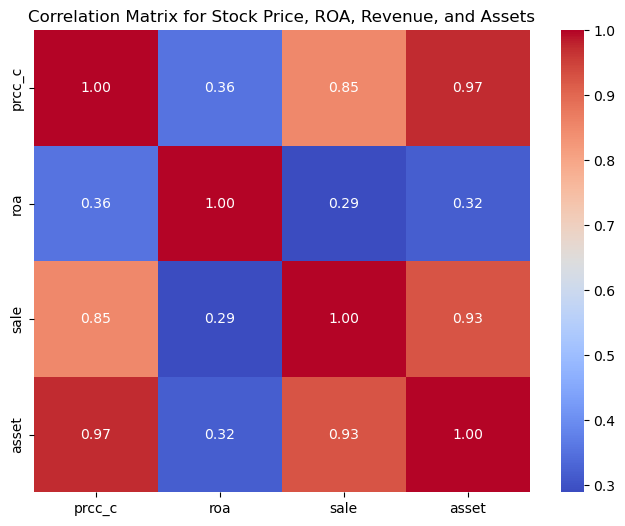

In [972]:
import matplotlib.pyplot as plt
import seaborn as sns

#(OpenAI, 2024)
# Calculate the correlation matrix for the variables
correlation_data = caseys_data[['prcc_c', 'roa', 'sale', 'asset']].corr()

# Plot the correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_data, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix for Stock Price, ROA, Revenue, and Assets")
plt.show()

### ChatGPT Reference Link

https://chatgpt.com/share/67022422-8aec-8009-ac48-1716885fd875